# Exploratory Data Analysis using Python - A Case Study

*Analyzing responses from the Stack Overflow Annual Developer Survey 2020*

### Part 9 of "Data Analysis with Python: Zero to Pandas"

This tutorial is the ninth in a series on the introduction to programming and data analysis using the Python language. These tutorials take a practical coding-based approach, and the best way to learn the material is to execute the code and experiment with the examples. Check out the full series here: 

1. [First Steps with Python and Jupyter](https://jovian.ml/aakashns/first-steps-with-python)
2. [A Quick Tour of Variables and Data Types](https://jovian.ml/aakashns/python-variables-and-data-types)
3. [Branching using Conditional Statements and Loops](https://jovian.ml/aakashns/python-branching-and-loops)
4. [Writing Reusable Code Using Functions](https://jovian.ml/aakashns/python-functions-and-scope)
5. [Reading from and Writing to Files](https://jovian.ml/aakashns/python-os-and-filesystem)
6. [Numerical Computing with Python and Numpy](https://jovian.ml/aakashns/python-numerical-computing-with-numpy)
7. [Analyzing Tabular Data using Pandas](https://jovian.ml/aakashns/python-pandas-data-analysis)
8. [Data Visulation using Matplotlib & Seaborn](https://jovian.ml/aakashns/python-matplotlib-data-visualization)
9. [Exploratory Data Analysis - A Case Study](https://jovian.ml/aakashns/python-eda-stackoverflow-survey)

## How to run the code

This tutorial hosted on [Jovian.ml](https://www.jovian.ml), a platform for sharing data science projects online. You can "run" this tutorial and experiment with the code examples in a couple of ways: *using free online resources* (recommended) or *on your own computer*.

>  This tutorial is a [Jupyter notebook](https://jupyter.org) - a document made of "cells", which can contain explanations in text or code written in Python. Code cells can be executed and their outputs e.g. numbers, messages, graphs, tables, files etc. can be viewed within the notebook, which makes it a really powerful platform for experimentation and analysis. Don't afraid to experiment with the code & break things - you'll learn a lot by encoutering and fixing errors. You can use the "Kernel > Restart & Clear Output" menu option to clear all outputs and start again from the top of the notebook.

### Option 1: Running using free online resources (1-click, recommended)

The easiest way to start executing this notebook is to click the "Run" button at the top of this page, and select "Run on Binder". This will run the notebook on [mybinder.org](https://mybinder.org), a free online service for running Jupyter notebooks. You can also select "Run on Colab" or "Run on Kaggle", but you'll need to create an account on [Google Colab](https://colab.research.google.com) or [Kaggle](https://kaggle.com) to use these platforms.


### Option 2: Running on your computer locally

You'll need to install Python and download this notebook on your computer to run in locally. We recommend using the [Conda](https://docs.conda.io/en/latest/) distribution of Python. Here's what you need to do to get started:

1. Install Conda by [following these instructions](https://conda.io/projects/conda/en/latest/user-guide/install/index.html). Make sure to add Conda binaries to your system `PATH` to be able to run the `conda` command line tool from your Mac/Linux terminal or Windows command prompt. 


2. Create and activate a [Conda virtual environment](https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html) called `zerotopandas` which you can use for this tutorial series:
```
conda create -n zerotopandas -y python=3.8 
conda activate zerotopandas
```
You'll need to create the environment only once, but you'll have to activate it every time want to run the notebook. When the environment is activated, you should be able to see a prefix `(zerotopandas)` within your terminal or command prompt.


3. Install the required Python libraries within the environment by the running the following command on your  terminal or command prompt:
```
pip install jovian jupyter numpy pandas matplotlib seaborn opendatasets --upgrade
```

4. Download the notebook for this tutorial using the `jovian clone` command:
```
jovian clone aakashns/python-eda-stackoverflow-survey
```
The notebook is downloaded to the directory `python-eda-stackoverflow-survey`.


5. Enter the project directory and start the Jupyter notebook:
```
cd python-eda-stackoverflow-survey
jupyter notebook
```

6. You can now access Jupyter's web interface by clicking the link that shows up on the terminal or by visiting http://localhost:8888 on your browser. Click on the notebook `python-eda-stackoverflow-survey.ipynb` to open it and run the code. If you want to type out the code yourself, you can also create a new notebook using the "New" button.

## Introduction

We'll use the StackOverflow developer survey dataset for our analysis. This is an annual survey conducted by StackOverflow, and you can find the raw data & results here: https://insights.stackoverflow.com/survey.

There are several options for getting the dataset into Jupyter:

- Download the CSV manually and upload it via Jupyter's GUI
- Use the `urlretrieve` function from the `urllib.request` to download CSV files from a raw URL directly
- Use a helper library e.g. [`opendatasets`](https://github.com/JovianML/opendatasets), which contains a collection of curated datasets and provides a function for directly download.

We'll use the `opendatasets` helper library to download the files.

In [1]:
import opendatasets as od

In [2]:
od.download('stackoverflow-developer-survey-2020')

Using downloaded and verified file: .\stackoverflow-developer-survey-2020\survey_results_public.csv
Using downloaded and verified file: .\stackoverflow-developer-survey-2020\survey_results_schema.csv
Using downloaded and verified file: .\stackoverflow-developer-survey-2020\README.txt


Let's verify that the dataset was downloaded into the directory `stackoverflow-developer-survey-2020`, and retrieve the list of files in the dataset.

In [3]:
import os

In [4]:
os.listdir('stackoverflow-developer-survey-2020')

['README.txt', 'survey_results_public.csv', 'survey_results_schema.csv']

You can go through the downloaded files using `File > Open` menu option in Jupyter. It seems like the dataset contains 3 files:

- `README.txt` - containing information about the dataset
- `survey_results_schema.csv` - containing the list of questions (and short codes for each question)
- `survey_results_public.csv` - the full list of responses to the questions 

Let's load the CSV files using the Pandas library. We'll use the name `survey_raw_df` for the data frame, to indicate that this is unprocessed data that which we might clean, filter and modify to prepare a data frame that's ready for analysis.

In [5]:
import pandas as pd

In [6]:
survey_raw_df = pd.read_csv('stackoverflow-developer-survey-2020/survey_results_public.csv')

In [7]:
survey_raw_df

,Respondent,MainBranch,Hobbyist,Age,Age1stCode,CompFreq,CompTotal,ConvertedComp,Country,CurrencyDesc,...,SurveyEase,SurveyLength,Trans,UndergradMajor,WebframeDesireNextYear,WebframeWorkedWith,WelcomeChange,WorkWeekHrs,YearsCode,YearsCodePro
0,1,I am a developer by profession,Yes,NaN,13,Monthly,NaN,NaN,Germany,European Euro,...,Neither easy nor difficult,Appropriate in length,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET;ASP.NET Core,Just as welcome now as I felt last year,50.0,36,27
1,2,I am a developer by profession,No,NaN,19,NaN,NaN,NaN,United Kingdom,Pound sterling,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat more welcome now than last year,NaN,7,4
2,3,I code primarily as a hobby,Yes,NaN,15,NaN,NaN,NaN,Russian Federation,NaN,...,Neither easy nor difficult,Appropriate in length,NaN,NaN,NaN,NaN,Somewhat more welcome now than last year,NaN,4,NaN
3,4,I am a developer by profession,Yes,25.0,18,NaN,NaN,NaN,Albania,Albanian lek,...,NaN,NaN,No,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat less welcome now than last year,40.0,7,4
4,5,"I used to be a developer by profession, but no...",Yes,31.0,16,NaN,NaN,NaN,United States,NaN,...,Easy,Too short,No,"Computer science, computer engineering, or sof...",Django;Ruby on Rails,Ruby on Rails,Just as welcome now as I felt last year,NaN,15,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,64858,NaN,Yes,NaN,16,NaN,NaN,NaN,United States,NaN,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,NaN,NaN,10,Less than 1 year
64457,64867,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Morocco,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64458,64898,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Viet Nam,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64459,64925,NaN,Yes,NaN,NaN,NaN,NaN,NaN,Poland,NaN,...,NaN,NaN,NaN,NaN,Angular;Angular.js;React.js,NaN,NaN,NaN,NaN,NaN


The dataset contains over 64,000 responses to 60 questions (although many questions are optional). The responses have been anonymized and there's no personally identifiable information available to us - although each respondent has been assigned a randomized respondent ID.

Let's view the list of columns in the data frame. 

In [8]:
survey_raw_df.columns

Index(['Respondent', 'MainBranch', 'Hobbyist', 'Age', 'Age1stCode', 'CompFreq',
       'CompTotal', 'ConvertedComp', 'Country', 'CurrencyDesc',
       'CurrencySymbol', 'DatabaseDesireNextYear', 'DatabaseWorkedWith',
       'DevType', 'EdLevel', 'Employment', 'Ethnicity', 'Gender', 'JobFactors',
       'JobSat', 'JobSeek', 'LanguageDesireNextYear', 'LanguageWorkedWith',
       'MiscTechDesireNextYear', 'MiscTechWorkedWith',
       'NEWCollabToolsDesireNextYear', 'NEWCollabToolsWorkedWith', 'NEWDevOps',
       'NEWDevOpsImpt', 'NEWEdImpt', 'NEWJobHunt', 'NEWJobHuntResearch',
       'NEWLearn', 'NEWOffTopic', 'NEWOnboardGood', 'NEWOtherComms',
       'NEWOvertime', 'NEWPurchaseResearch', 'NEWPurpleLink', 'NEWSOSites',
       'NEWStuck', 'OpSys', 'OrgSize', 'PlatformDesireNextYear',
       'PlatformWorkedWith', 'PurchaseWhat', 'Sexuality', 'SOAccount',
       'SOComm', 'SOPartFreq', 'SOVisitFreq', 'SurveyEase', 'SurveyLength',
       'Trans', 'UndergradMajor', 'WebframeDesireNextYear',
  

It appears that short codes for questions are used as column names. 

We can refer to the schema file to see the full text of each question. The schema file contains only two columns: `Column` and `QuestionText`, so we can load it as Pandas Series with `Column` as the index and the  `QuestionText` as the value.

In [9]:
schema_fname = 'stackoverflow-developer-survey-2020/survey_results_schema.csv'
schema_raw = pd.read_csv(schema_fname, index_col='Column').QuestionText

In [10]:
schema_raw

Column
Respondent            Randomized respondent ID number (not in order ...
MainBranch            Which of the following options best describes ...
Hobbyist                                        Do you code as a hobby?
Age                   What is your age (in years)? If you prefer not...
Age1stCode            At what age did you write your first line of c...
                                            ...                        
WebframeWorkedWith    Which web frameworks have you done extensive d...
WelcomeChange         Compared to last year, how welcome do you feel...
WorkWeekHrs           On average, how many hours per week do you wor...
YearsCode             Including any education, how many years have y...
YearsCodePro          NOT including education, how many years have y...
Name: QuestionText, Length: 61, dtype: object

We can now use `schema_raw` to retrieve the full question text for any column in `survey_raw_df`.

In [11]:
schema_raw['YearsCodePro']

'NOT including education, how many years have you coded professionally (as a part of your work)?'

We've now loaded the dataset, and we're ready to move on to the next step of preprocessing & cleaning the data for our analysis.

### Save and upload your work

Whether you're running this Jupyter notebook on an online service like Binder or on your local machine, it's important to save your work from time, so that you can access it later, or share it online. You can upload this notebook to your Jovian.ml account using the `jovian` Python library.

In [12]:
# Select a project name
project = 'python-eda-stackoverflow-survey'

In [13]:
# Install the Jovian library
!pip install jovian --upgrade --quiet

In [14]:
import jovian

In [15]:
jovian.commit(project = project, filename = project)

<IPython.core.display.Javascript object>

[jovian] Attempting to save notebook..
[jovian] Updating notebook "hatziq/python-eda-stackoverflow-survey" on https://jovian.ml/
[jovian] Uploading notebook..
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/hatziq/python-eda-stackoverflow-survey


'https://jovian.ml/hatziq/python-eda-stackoverflow-survey'

`jovian.commit` uploads the notebook to your [Jovian.ml](https://jovian.ml) account, captures the Python environment and creates a shareable link for your notebook as shown above. You can use this link to share your work and let anyone (including you) run your notebooks and reproduce your work.

## Data Preparation & Cleaning

While the survey responses contain a wealth of information, we'll limit our analysis to the following areas:

- Demographics of the survey respondents & the global programming community
- Distribution of programming skills, experience and preferences
- Employment-related information, preferences & opinions

Let's select a subset of columns with the relevant data for our analysis.

In [16]:
selected_columns = [
    # Demographics
    'Country',
    'Age',
    'Gender',
    'EdLevel',
    'UndergradMajor',
    
    # Programming experience
    'Hobbyist',
    'Age1stCode',
    'YearsCode',
    'YearsCodePro',
    'LanguageWorkedWith',
    'LanguageDesireNextYear',
    'NEWLearn',
    'NEWStuck',
    
    # Employment
    'Employment',
    'DevType',
    'WorkWeekHrs',
    'JobSat',
    'JobFactors',
    'NEWOvertime',
    'NEWEdImpt'
    
]

In [17]:
len(selected_columns)

20

Let's extract a copy of the data from these columns into a new data frame `survey_df`, which we can continue to modify further without affecting the original data frame.

In [18]:
survey_df = survey_raw_df[selected_columns].copy()

In [19]:
schema = schema_raw[selected_columns]

Let's view some basic information about the data frame.

In [20]:
survey_df.shape

(64461, 20)

Let's see what do these columns mean ie what questions do they correspond to.

In [21]:
for question in schema.values:
    print(question)

Where do you live?
What is your age (in years)? If you prefer not to answer, you may leave this question blank.
Which of the following describe you, if any? Please check all that apply. If you prefer not to answer, you may leave this question blank.
Which of the following best describes the highest level of formal education that you’ve completed?
What was your primary field of study?
Do you code as a hobby?
At what age did you write your first line of code or program? (e.g., webpage, Hello World, Scratch project)
Including any education, how many years have you been coding in total?
NOT including education, how many years have you coded professionally (as a part of your work)?
Which programming, scripting, and markup languages have you done extensive development work in over the past year, and which do you want to work in over the next year? (If you both worked with the language and want to continue to do so, please check both boxes in that row.)
Which programming, scripting, and marku

In [22]:
survey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 64072 non-null  object 
 1   Age                     45446 non-null  float64
 2   Gender                  50557 non-null  object 
 3   EdLevel                 57431 non-null  object 
 4   UndergradMajor          50995 non-null  object 
 5   Hobbyist                64416 non-null  object 
 6   Age1stCode              57900 non-null  object 
 7   YearsCode               57684 non-null  object 
 8   YearsCodePro            46349 non-null  object 
 9   LanguageWorkedWith      57378 non-null  object 
 10  LanguageDesireNextYear  54113 non-null  object 
 11  NEWLearn                56156 non-null  object 
 12  NEWStuck                54983 non-null  object 
 13  Employment              63854 non-null  object 
 14  DevType                 49370 non-null

Most columns have the data type `object`, either because they contain values of different types, or they contain empty values, which are represented using `NaN`. It appears that every column contains some empty values, since the Non-Null count for every column is lower than the total number of rows (64461). We'll need to deal with empty values and manually adjust the data type for each column on a case-by-case basis. 

Only two of the columns were detected as numeric columns (`Age` and `WorkWeekHrs`), even though there are a few other columns which have mostly numeric values. To make our analysis easier, let's convert some other columns into numeric data types, while ignoring any non-numeric value (they will get converted to NaNs)

In [23]:
survey_df['Age1stCode'] = pd.to_numeric(survey_df.Age1stCode, errors='coerce')
survey_df['YearsCode'] = pd.to_numeric(survey_df.YearsCode, errors='coerce')
survey_df['YearsCodePro'] = pd.to_numeric(survey_df.YearsCodePro, errors='coerce')

In [24]:
survey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64461 entries, 0 to 64460
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 64072 non-null  object 
 1   Age                     45446 non-null  float64
 2   Gender                  50557 non-null  object 
 3   EdLevel                 57431 non-null  object 
 4   UndergradMajor          50995 non-null  object 
 5   Hobbyist                64416 non-null  object 
 6   Age1stCode              57473 non-null  float64
 7   YearsCode               56784 non-null  float64
 8   YearsCodePro            44133 non-null  float64
 9   LanguageWorkedWith      57378 non-null  object 
 10  LanguageDesireNextYear  54113 non-null  object 
 11  NEWLearn                56156 non-null  object 
 12  NEWStuck                54983 non-null  object 
 13  Employment              63854 non-null  object 
 14  DevType                 49370 non-null

Let's now view some basic statistics about the the numeric columns.

In [25]:
survey_df.describe()

,Age,Age1stCode,YearsCode,YearsCodePro,WorkWeekHrs
count,45446.000000,57473.000000,56784.000000,44133.000000,41151.000000
mean,30.834111,15.476572,12.782051,8.869667,40.782174
std,9.585392,5.114081,9.490657,7.759961,17.816383
min,1.000000,5.000000,1.000000,1.000000,1.000000
25%,24.000000,12.000000,6.000000,3.000000,40.000000
50%,29.000000,15.000000,10.000000,6.000000,40.000000
75%,35.000000,18.000000,17.000000,12.000000,44.000000
max,279.000000,85.000000,50.000000,50.000000,475.000000


In [26]:
# View what does the column mean
print(schema['YearsCode'])
print(schema['YearsCodePro'])

Including any education, how many years have you been coding in total?
NOT including education, how many years have you coded professionally (as a part of your work)?


In [27]:
survey_df['YearsCode'].unique()

array([36.,  7.,  4., 15.,  6., 17.,  8., 10., 35.,  5., 37., 19.,  9.,
       22., 30., 23., 20.,  2., nan,  3., 13., 25., 16., 43., 11., 38.,
       33., 24., 21., 12., 40., 27., 50., 46., 14., 18., 28., 32., 44.,
       26., 42., 31., 34., 29.,  1., 39., 41., 45., 47., 49., 48.])

There seems to be a problem with the age column, as the minimum value is 1 and max value is 279. This is a common issues with surveys: responses may contain invalid values due to accidental or intentional errors while responding. A simple fix would be ignore the rows where the value in the age column is higher than 100 years or lower than 10 years as invalid survey responses. This can be done using the `.drop` method, [as explained here](https://www.geeksforgeeks.org/drop-rows-from-the-dataframe-based-on-certain-condition-applied-on-a-column/).

In [28]:
# Drop must be via the index of rows satisfying the condition
survey_df.drop(survey_df[survey_df.Age < 10].index, inplace=True)
survey_df.drop(survey_df[survey_df.Age > 100].index, inplace=True)

The same hold true for `WorkWeekHrs`. Let's ignore entries where the value for the column is higher than 140 hours. (~20 hours per day).

In [29]:
survey_df.drop(survey_df[survey_df.WorkWeekHrs > 140].index, inplace=True)

In [30]:
# View the summary statistics for numeric columns are dropping irrelevant rows
survey_df.describe()

,Age,Age1stCode,YearsCode,YearsCodePro,WorkWeekHrs
count,45319.000000,57326.000000,56636.000000,43993.000000,41002.000000
mean,30.832322,15.475317,12.783883,8.873003,40.024395
std,9.505965,5.114952,9.494519,7.762089,10.630010
min,10.000000,5.000000,1.000000,1.000000,1.000000
25%,24.000000,12.000000,6.000000,3.000000,40.000000
50%,29.000000,15.000000,10.000000,6.000000,40.000000
75%,35.000000,18.000000,17.000000,12.000000,43.000000
max,99.000000,85.000000,50.000000,50.000000,140.000000


The gender column also allows picking multiple options, but to simplify our analysis, we'll remove values containing more than option.

In [31]:
survey_df['Gender'].value_counts()

Man                                                            45895
Woman                                                           3835
Non-binary, genderqueer, or gender non-conforming                385
Man;Non-binary, genderqueer, or gender non-conforming            121
Woman;Non-binary, genderqueer, or gender non-conforming           92
Woman;Man                                                         73
Woman;Man;Non-binary, genderqueer, or gender non-conforming       25
Name: Gender, dtype: int64

In [32]:
import numpy as np

In [33]:
survey_df.where(~(survey_df.Gender.str.contains(';', na=False)), np.nan, inplace=True)

.where takes a condition. Wherever the condition is satisfied, it replaces the value with np.nan. 

In [34]:
# View the genders after replacements
survey_df['Gender'].value_counts()

Man                                                  45895
Woman                                                 3835
Non-binary, genderqueer, or gender non-conforming      385
Name: Gender, dtype: int64

In [35]:
# Since we did not replace last category, have to do it again
survey_df.where(~(survey_df.Gender.str.contains(',', na=False)), np.nan, inplace=True)

In [36]:
# View the genders after replacements
survey_df['Gender'].value_counts()

Man      45895
Woman     3835
Name: Gender, dtype: int64

In [37]:
survey_df['Gender'].isna().sum()

14576

In [38]:
len(survey_df)

64306

We've now cleaned up and prepared the dataset for analysis. Let's take a look at sample of rows from the data frame.

In [39]:
survey_df.sample(10)

,Country,Age,Gender,EdLevel,UndergradMajor,Hobbyist,Age1stCode,YearsCode,YearsCodePro,LanguageWorkedWith,LanguageDesireNextYear,NEWLearn,NEWStuck,Employment,DevType,WorkWeekHrs,JobSat,JobFactors,NEWOvertime,NEWEdImpt
9333,India,28.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,18.0,10.0,3.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,Every few months,Visit Stack Overflow,Employed full-time,"Designer;Developer, back-end;Developer, deskto...",48.0,Very satisfied,Flex time or a flexible schedule;Office enviro...,Often: 1-2 days per week or more,Very important
12964,India,34.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",No,15.0,14.0,8.0,NaN,NaN,Once a year,Call a coworker or friend;Go for a walk or oth...,Employed full-time,"Academic researcher;Designer;Engineer, data;En...",50.0,Neither satisfied nor dissatisfied,How widely used or impactful my work output wo...,Occasionally: 1-2 days per quarter but less th...,Somewhat important
16322,Canada,31.0,Man,"Associate degree (A.A., A.S., etc.)","Computer science, computer engineering, or sof...",Yes,15.0,12.0,10.0,Bash/Shell/PowerShell;C#;JavaScript;SQL;TypeSc...,Bash/Shell/PowerShell;C#;JavaScript;SQL;TypeSc...,Once a year,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,"Developer, back-end;Developer, full-stack;DevO...",40.0,Neither satisfied nor dissatisfied,Flex time or a flexible schedule;Remote work o...,Occasionally: 1-2 days per quarter but less th...,Fairly important
40346,Malaysia,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,15.0,15.0,NaN,NaN,NaN,NaN,NaN,Employed full-time,"Designer;Developer, desktop or enterprise appl...",NaN,NaN,Diversity of the company or organization;Langu...,NaN,NaN
6869,France,36.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Fine arts or performing arts (such as graphic ...,No,24.0,9.0,7.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,NaN,Once every few years,Visit Stack Overflow;Do other work and come ba...,Employed full-time,"Developer, back-end;Developer, front-end",39.0,Slightly dissatisfied,"Industry that I’d be working in;Languages, fra...",Occasionally: 1-2 days per quarter but less th...,Somewhat important
5328,India,24.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Computer science, computer engineering, or sof...",Yes,20.0,6.0,3.0,C#;C++;HTML/CSS;Java;JavaScript;SQL,C#;HTML/CSS;Java;JavaScript;Kotlin;Python;Scal...,Every few months,Visit Stack Overflow;Visit another developer c...,Employed full-time,"Developer, back-end;Developer, full-stack",54.0,Slightly dissatisfied,Diversity of the company or organization;Finan...,Often: 1-2 days per week or more,Somewhat important
44245,Israel,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,C;C++;Python,NaN,Every few months,NaN,"Independent contractor, freelancer, or self-em...",NaN,NaN,NaN,NaN,NaN,NaN
30725,Sweden,27.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,15.0,10.0,3.0,Java;JavaScript;SQL,Java;JavaScript;SQL;TypeScript,Once a year,Meditate;Call a coworker or friend;Visit Stack...,"Independent contractor, freelancer, or self-em...","Database administrator;Developer, back-end;Dev...",NaN,Slightly satisfied,"Languages, frameworks, and other technologies ...",Often: 1-2 days per week or more,Fairly important
31150,Israel,45.0,Man,Some college/university study without earning ...,"Information systems, information technology, o...",No,12.0,19.0,14.0,Bash/Shell/PowerShell;C#;Python,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,Every few months,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,"Developer, back-end;Developer, desktop or ente...",47.0,Very satisfied,Remote work options;Office environment or comp...,Often: 1-2 days per week or more,Somew

Let's save and commit our work before continuing.

In [40]:
import jovian

In [41]:
jovian.commit(project = project, filename = project)

<IPython.core.display.Javascript object>

[jovian] Attempting to save notebook..
[jovian] Updating notebook "hatziq/python-eda-stackoverflow-survey" on https://jovian.ml/
[jovian] Uploading notebook..
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/hatziq/python-eda-stackoverflow-survey


'https://jovian.ml/hatziq/python-eda-stackoverflow-survey'

## Exploratory Analysis and Visualization

Before we can ask interesting questions about the survey responses, it would help to understand what the demographics i.e. country, age, gender, education level, employment level etc. of the respondents look like. It's important to explore these variable in order to understand how representative the survey is of the worldwide programming community, as a survey of this scale generally tends to have some [selection bias](https://en.wikipedia.org/wiki/Selection_bias).

Let's begin by importing `matplotlib.pyplot` and `seaborn`.

In [42]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

### Country

Let's look at the number of countries from which there are responses in the survey, and plot the 10 countries with the highest number of responses.

In [43]:
schema.Country

'Where do you live?'

In [44]:
survey_df.Country.nunique()

183

We can identify the countries with the highest number of respondents using the `value_counts` method.

In [45]:
top_countries = survey_df.Country.value_counts().head(15)
top_countries

United States         12240
India                  8352
United Kingdom         3846
Germany                3835
Canada                 2152
France                 1866
Brazil                 1799
Netherlands            1325
Poland                 1256
Australia              1186
Spain                  1148
Italy                  1109
Russian Federation     1084
Sweden                  869
Pakistan                802
Name: Country, dtype: int64

In [46]:
# Check number of respondents from Singapore
len(survey_df[survey_df['Country'] == 'Singapore'])

227

We can visualize this information using a bar chart.

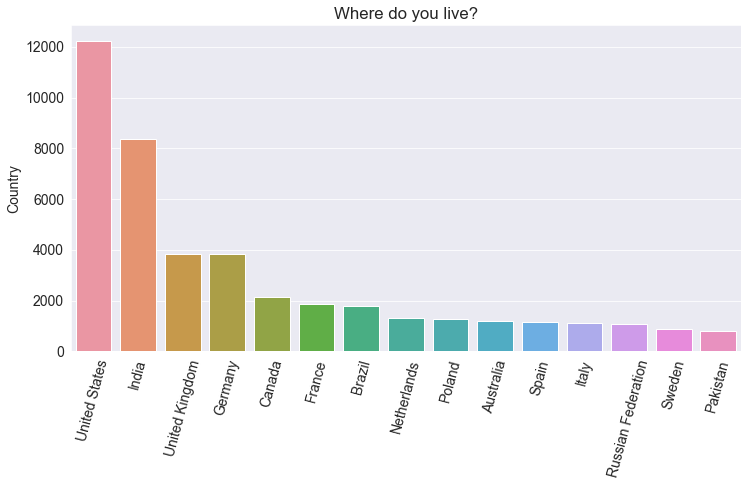

In [47]:
plt.figure(figsize=(12,6))
plt.xticks(rotation=75)
plt.title(schema.Country)
sns.barplot(top_countries.index, top_countries);

It appears the that a disproportionately high number of respondents are from USA & India - which one might expect since these countries have the highest populations (apart from China), and since the Survey is in English, which is the common language used by professionals in US, India & UK. We can already see that the survey may not be representative of the entire programming community - especially from non-English speaking countries.

**Exercise**:
Try finding the percentage of responses from English-speaking vs. non-English speaking countries. You can use [this list of languages spoken in different countries](https://github.com/JovianML/opendatasets/blob/master/data/countries-languages-spoken/countries-languages.csv).

### Finding the number of respondents that speak English

In [48]:
# Download dataset with mapping of country to spoken languages
import requests
raw_csv = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/countries-languages-spoken/countries-languages.csv'
req = requests.get(raw_csv)
url_content = req.content
csv_file = open('country_languages.csv', 'wb')
csv_file.write(url_content)
csv_file.close()

In [49]:
# Import dataset into notebook
country_languages_df = pd.read_csv('country_languages.csv')
country_languages_df.head()

,Country,Languages Spoken
0,Afghanistan,"Dari Persian, Pashtu (both official), other Tu..."
1,Albania,"Albanian (Tosk is the official dialect), Greek"
2,Algeria,"Arabic (official), French, Berber dialects"
3,Andorra,"Catalán (official), French, Castilian, Portuguese"
4,Angola,"Portuguese (official), Bantu and other African..."


In [50]:
# Join to get the langauges spoken column on the original df
survey_df_with_language = survey_df.merge(country_languages_df, on = 'Country')
survey_df_with_language.head()

,Country,Age,Gender,EdLevel,UndergradMajor,Hobbyist,Age1stCode,YearsCode,YearsCodePro,LanguageWorkedWith,...,NEWLearn,NEWStuck,Employment,DevType,WorkWeekHrs,JobSat,JobFactors,NEWOvertime,NEWEdImpt,Languages Spoken
0,Germany,NaN,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,13.0,36.0,27.0,C#;HTML/CSS;JavaScript,...,Once a year,Visit Stack Overflow;Go for a walk or other ph...,"Independent contractor, freelancer, or self-em...","Developer, desktop or enterprise applications;...",50.0,Slightly satisfied,"Languages, frameworks, and other technologies ...",Often: 1-2 days per week or more,Fairly important,German
1,Germany,NaN,Man,"Secondary school (e.g. American high school, G...",NaN,No,14.0,6.0,4.0,HTML/CSS;Java;JavaScript,...,Once a year,Play games;Visit Stack Overflow;Watch help / t...,Employed full-time,"Designer;Developer, front-end;Developer, mobile",NaN,Slightly satisfied,Diversity of the company or organization;Langu...,Never,Fairly important,German
2,Germany,27.0,Man,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Another engineering discipline (such as civil,...",Yes,14.0,8.0,3.0,Bash/Shell/PowerShell;C#;C++,...,Every few months,Play games;Call a coworker or friend;Visit Sta...,Employed full-time,"Developer, back-end;Developer, desktop or ente...",40.0,Very satisfied,"Flex time or a flexible schedule;Languages, fr...",Rarely: 1-2 days per year or less,Fairly important,German
3,Germany,45.0,Man,"Professional degree (JD, MD, etc.)","Another engineering discipline (such as civil,...",Yes,14.0,30.0,20.0,Bash/Shell/PowerShell;Java;Kotlin;PHP;SQL,...,Every few months,Call a coworker or friend;Visit Stack Overflow...,Employed full-time,"Developer, back-end",42.0,Very satisfied,"Languages, frameworks, and other technologies ...",Often: 1-2 days per week or more,Very important,German
4,Germany,29.0,Man,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",Yes,15.0,10.0,NaN,HTML/CSS;Java;JavaScript;SQL;TypeScript,...,Once a year,Call a coworker or friend;Visit Stack Overflow...,"Not employed, but looking for work","Developer, back-end;Developer, full-stack",NaN,NaN,"Flex time or a flexible schedule;Languages, fr...",NaN,Very important,German


In [51]:
# Check if Afghanistan has multiple languages listed
survey_df_with_language[survey_df_with_language['Country'] == 'Afghanistan'].head(1)

,Country,Age,Gender,EdLevel,UndergradMajor,Hobbyist,Age1stCode,YearsCode,YearsCodePro,LanguageWorkedWith,...,NEWLearn,NEWStuck,Employment,DevType,WorkWeekHrs,JobSat,JobFactors,NEWOvertime,NEWEdImpt,Languages Spoken
59385,Afghanistan,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Another engineering discipline (such as civil,...",No,14.0,4.0,2.0,JavaScript,...,Once every few years,Visit Stack Overflow;Go for a walk or other ph...,Employed full-time,"Database administrator;Developer, back-end;Dev...",90.0,Very satisfied,Industry that I’d be working in;Diversity of t...,Often: 1-2 days per week or more,Very important,"Dari Persian, Pashtu (both official), other Tu..."


In [52]:
survey_df_with_language.columns

Index(['Country', 'Age', 'Gender', 'EdLevel', 'UndergradMajor', 'Hobbyist',
       'Age1stCode', 'YearsCode', 'YearsCodePro', 'LanguageWorkedWith',
       'LanguageDesireNextYear', 'NEWLearn', 'NEWStuck', 'Employment',
       'DevType', 'WorkWeekHrs', 'JobSat', 'JobFactors', 'NEWOvertime',
       'NEWEdImpt', 'Languages Spoken'],
      dtype='object')

In [53]:
english_speakers = survey_df_with_language[survey_df_with_language['Languages Spoken'].str.contains("English")]

In [54]:
print("Total english respondents: ", len(english_speakers))

Total english respondents:  38391


In [55]:
english_speakers['Country'].value_counts()

United States          12240
India                   8352
United Kingdom          3846
Canada                  2152
Brazil                  1799
                       ...  
Nauru                      1
Fiji                       1
Antigua and Barbuda        1
Lesotho                    1
Marshall Islands           1
Name: Country, Length: 72, dtype: int64

In [56]:
# Check number of people from Singapore
len(english_speakers[english_speakers['Country'] == 'Singapore'])

227

In [57]:
# Compare with the original survey dataframe
len(survey_df[survey_df['Country'] == 'Singapore'])

227

### Age

The distribution of the age of respondents is another important factor to look at, and we can use a histogram to visualize it. 

Note that when we use the plt functions, all nan values are ignored

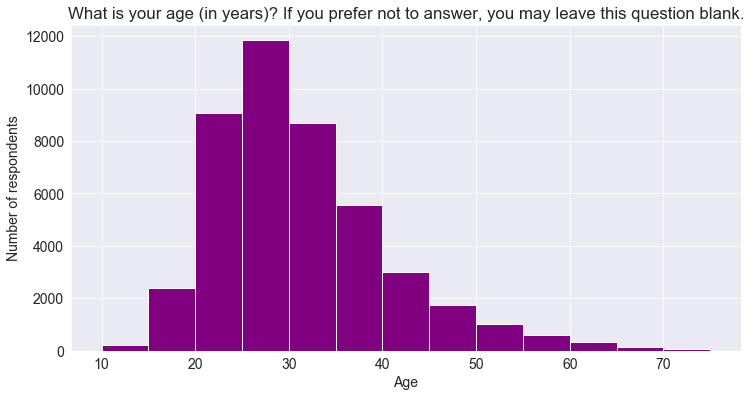

In [58]:
plt.figure(figsize=(12, 6))
plt.title(schema.Age)
plt.xlabel('Age')
plt.ylabel('Number of respondents')

plt.hist(survey_df.Age, bins=np.arange(10,80,5), color='purple');

It appears that a large percentage of respondents are in the age range of 20-45, which is somewhat representative of the programming community in general, as a lot of young people have taken up computer as their field of study or profession in the last 20 years.

**Exercise**: You may want to filter out responses by age (or age group), if you'd like to analyze and compare the results of the survey for different age groups. Create a new column called `AgeGroup` which contains values like `Less than 10 years`, `10-18 years`, `18-30 years`, `30-45 years`, `45-60 years`, `Older than 60 years`, and repeat the analysis in the rest of this notebook for each age group.

### Gender

Let's look at the distribution of responses for the Gender. It's a well known fact that women and non-binary genders are underrepresented in the programming community, so we might expect to see a skewed distribution here.

In [59]:
schema.Gender

'Which of the following describe you, if any? Please check all that apply. If you prefer not to answer, you may leave this question blank.'

In [60]:
gender_counts = survey_df.Gender.value_counts()
gender_counts

Man      45895
Woman     3835
Name: Gender, dtype: int64

A pie chart would be a good way to visualize the distribution.

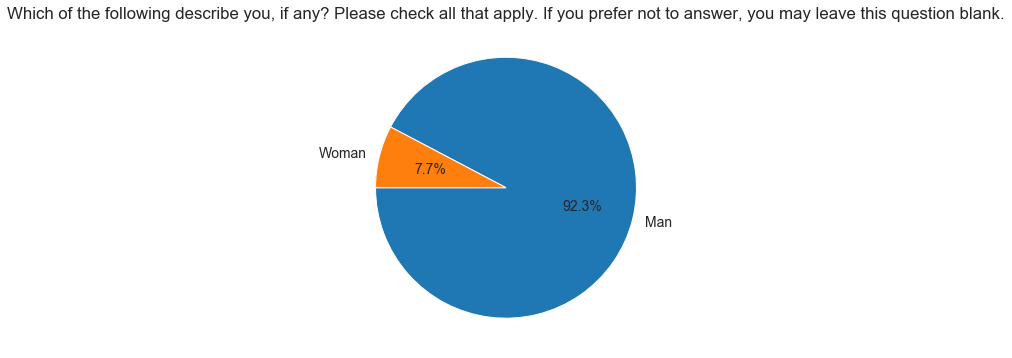

In [61]:
plt.figure(figsize=(12,6))
plt.title(schema.Gender)
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=180);

Only about 8% of survey respondents who have answered the question identify as women or non-binary. This number is lower than the overall percentage of women & non-binary genders in the programming community - which is estimated to be around 12%. 

**Exercise**: It would be interesting to compare the survey responses & preferences across genders, and you are encouraged to repeat this analysis with these breakdowns. How do the relative education levels differ across genders? How to salaries differ? You may find this analysis on the [Gender Divide in Data Science](https://medium.com/datadriveninvestor/exploratory-data-analysis-eda-understanding-the-gender-divide-in-data-science-roles-9faa5da44f5b) useful.

### Education Level

Formal education in computer science is often considered an important requirement of becoming a programmer. Let's see if this indeed the case, especially since there are many free resources & tutorials available online to learn programming. We'll use a horizontal bar plot to compare education levels of respondents.

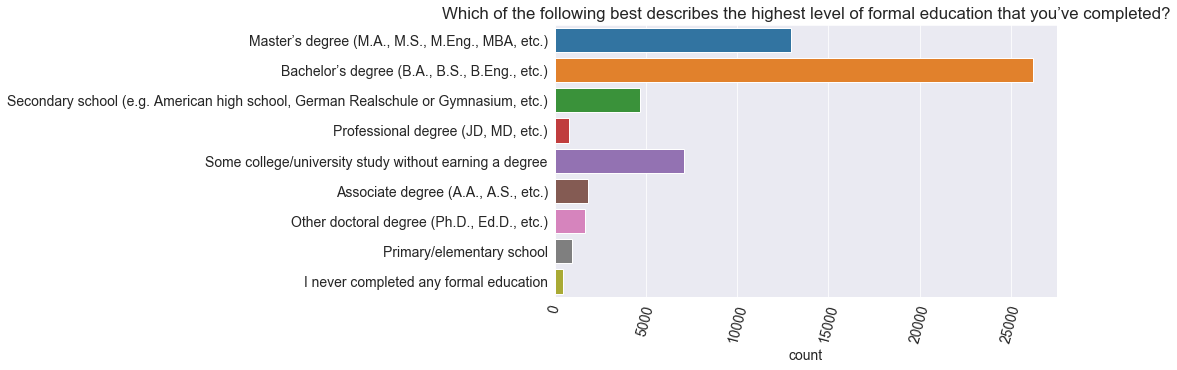

In [62]:
sns.countplot(y=survey_df.EdLevel)
plt.xticks(rotation=75);
plt.title(schema['EdLevel'])
plt.ylabel(None);

It appears that well over half of the respondents hold a bachelor's or master's degree, so most programmers definitely seem to have some college education, although it's not clear from this graph alone if they hold a degree in computer science.

**Exercises**: The graph currently shows the number of respondents for each option, can you modify it to show the percentage instead? Further, can you break down the graph to compare the percentages for each degree for men vs. women. 

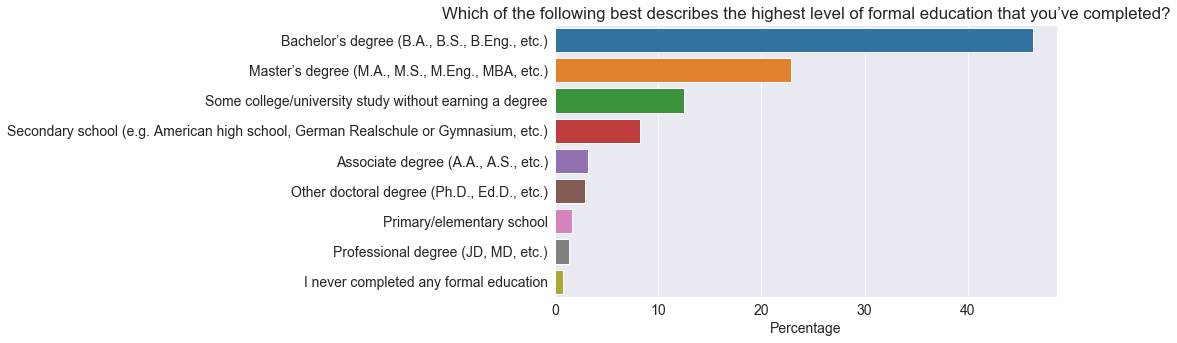

In [63]:
education_level_pct = survey_df.EdLevel.value_counts() * 100 / survey_df.EdLevel.count()
sns.barplot(education_level_pct, education_level_pct.index)

plt.title(schema.EdLevel)
plt.ylabel(None);
plt.xlabel('Percentage');

Let's also plot undergraduate majors, but this time we'll convert the numbers into percentages, and sort by percentage values to make it easier to visualize the order.

In [64]:
schema.UndergradMajor

'What was your primary field of study?'

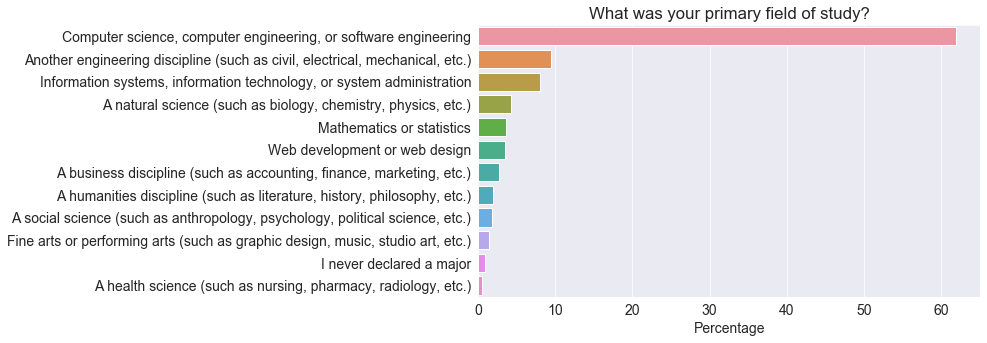

In [65]:
undergrad_pct = survey_df.UndergradMajor.value_counts() * 100 / survey_df.UndergradMajor.count()

sns.barplot(undergrad_pct, undergrad_pct.index)

plt.title(schema.UndergradMajor)
plt.ylabel(None);
plt.xlabel('Percentage');

It turns that 40% of programmers holding a college degree have a field of study other than computer science - which is very encouraging. This seems to suggest that while college education is helpful in general, you do not need to pursue a major in computer science to become a successful programmer.




In [66]:
# Remove entries with na values for the UndergradMajor
undergad_major_no_na = survey_df[survey_df['UndergradMajor'].notna()]

# Print the possible options available
undergad_major_no_na['UndergradMajor'].unique()

array(['Computer science, computer engineering, or software engineering',
       'Mathematics or statistics',
       'Another engineering discipline (such as civil, electrical, mechanical, etc.)',
       'A humanities discipline (such as literature, history, philosophy, etc.)',
       'A health science (such as nursing, pharmacy, radiology, etc.)',
       'Information systems, information technology, or system administration',
       'Web development or web design',
       'A natural science (such as biology, chemistry, physics, etc.)',
       'Fine arts or performing arts (such as graphic design, music, studio art, etc.)',
       'I never declared a major',
       'A social science (such as anthropology, psychology, political science, etc.)',
       'A business discipline (such as accounting, finance, marketing, etc.)'],
      dtype=object)

In [67]:
# Count number of ppl with category as computer science or information systems
num_with_background = len(undergad_major_no_na[undergad_major_no_na['UndergradMajor'].str.contains('computer')])
num_with_background += len(undergad_major_no_na[undergad_major_no_na['UndergradMajor'].str.contains('information')])
print(num_with_background)

35221


In [68]:
(gender_counts.index)

Index(['Man', 'Woman'], dtype='object')

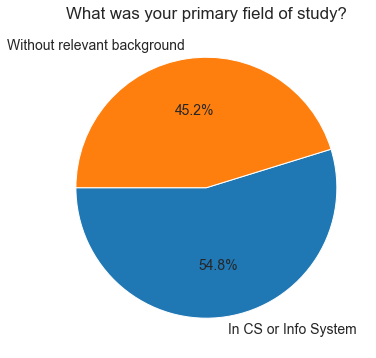

In [69]:
# Create Panda Series, for pie chart visualization
cs_background_dict = {'In CS or Info System' : num_with_background, 
                      'Without relevant background' : len(survey_df) - num_with_background} 
cs_background_series = pd.Series(cs_background_dict)

plt.figure(figsize=(12,6))
plt.title(schema.UndergradMajor)
plt.pie(cs_background_series, labels=cs_background_series.index, autopct='%1.1f%%', startangle=180);

**Exercises**: Analyze the results of the `NEWEdImpt` column for respondents who hold some college degree vs. those who don't. Do you notice any difference in opinion?

In [70]:
schema['NEWEdImpt']

'How important is a formal education, such as a university degree in computer science, to your career?'

In [84]:
schema['EdLevel']

'Which of the following best describes the highest level of formal education that you’ve completed?'

In [85]:
formal_education_without_na = survey_df[survey_df['NEWEdImpt'].notna()]

# Only extract out bachelors and above
formal_education_without_na = formal_education_without_na[formal_education_without_na['EdLevel'].notna()]
degree_terms = ['Bachelor', 'Master']
formal_education_without_na = formal_education_without_na[formal_education_without_na['EdLevel'].str.contains('|'.join(degree_terms))]

# Get value counts
formal_education_without_na_counts = formal_education_without_na['NEWEdImpt'].value_counts()

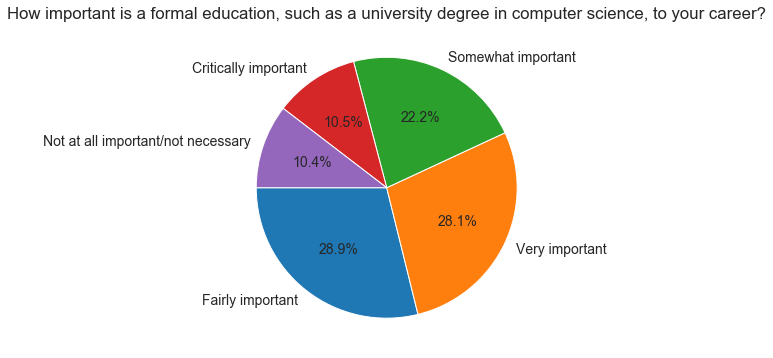

In [86]:
plt.figure(figsize=(12,6))
plt.title(schema.NEWEdImpt)
plt.pie(formal_education_without_na_counts, labels=formal_education_without_na_counts.index, autopct='%1.1f%%', startangle=180);

### Check if college graduates value their degree (CS/IS Degrees vs non CS-IS Degrees)

In [103]:
# Extract out people with a CS/IS degree background
formal_cs_background = survey_df.dropna(subset=['UndergradMajor', 'NEWEdImpt', 'EdLevel'])

# Filter out relevant majors
cs_terms = ['computer', 'system', 'web']
formal_cs_background = formal_cs_background[formal_cs_background['UndergradMajor'].str.contains('|'.join(cs_terms))]

# Filter out education level
degree_terms = ['Bachelor', 'Master']
formal_cs_background = formal_cs_background[formal_cs_background['EdLevel'].str.contains('|'.join(degree_terms))]

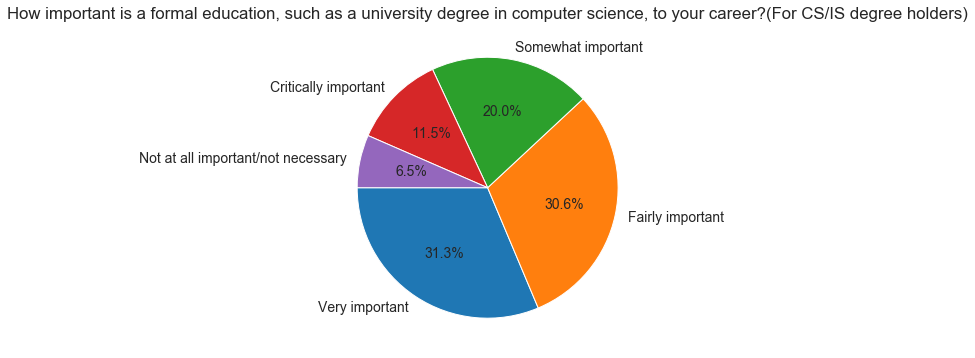

In [104]:
# Visualize how these people view their degrees
counts = formal_cs_background['NEWEdImpt'].value_counts()

plt.figure(figsize=(12,6))
plt.title(schema.NEWEdImpt + '(For CS/IS degree holders)')
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=180);

In [102]:
formal_cs_background['UndergradMajor'].unique()

array(['Computer science, computer engineering, or software engineering',
       'Information systems, information technology, or system administration',
       'Web development or web design'], dtype=object)

In [90]:
survey_df['UndergradMajor'].unique()

array(['Computer science, computer engineering, or software engineering',
       nan, 'Mathematics or statistics',
       'Another engineering discipline (such as civil, electrical, mechanical, etc.)',
       'A humanities discipline (such as literature, history, philosophy, etc.)',
       'A health science (such as nursing, pharmacy, radiology, etc.)',
       'Information systems, information technology, or system administration',
       'Web development or web design',
       'A natural science (such as biology, chemistry, physics, etc.)',
       'Fine arts or performing arts (such as graphic design, music, studio art, etc.)',
       'I never declared a major',
       'A social science (such as anthropology, psychology, political science, etc.)',
       'A business discipline (such as accounting, finance, marketing, etc.)'],
      dtype=object)

In [105]:
# Extract out people with a non-CS but STEM background
stem_background = survey_df.dropna(subset=['UndergradMajor', 'NEWEdImpt', 'EdLevel'])

# Filter out relevant majors
stem_terms = ['Mathematics', 'civil', 'health', 'chemistry']
stem_background = stem_background[stem_background['UndergradMajor'].str.contains('|'.join(stem_terms))]

# Filter out education level
degree_terms = ['Bachelor', 'Master']
stem_background = stem_background[stem_background['EdLevel'].str.contains('|'.join(degree_terms))]

In [107]:
stem_background['UndergradMajor'].unique()

array(['Mathematics or statistics',
       'Another engineering discipline (such as civil, electrical, mechanical, etc.)',
       'A natural science (such as biology, chemistry, physics, etc.)',
       'A health science (such as nursing, pharmacy, radiology, etc.)'],
      dtype=object)

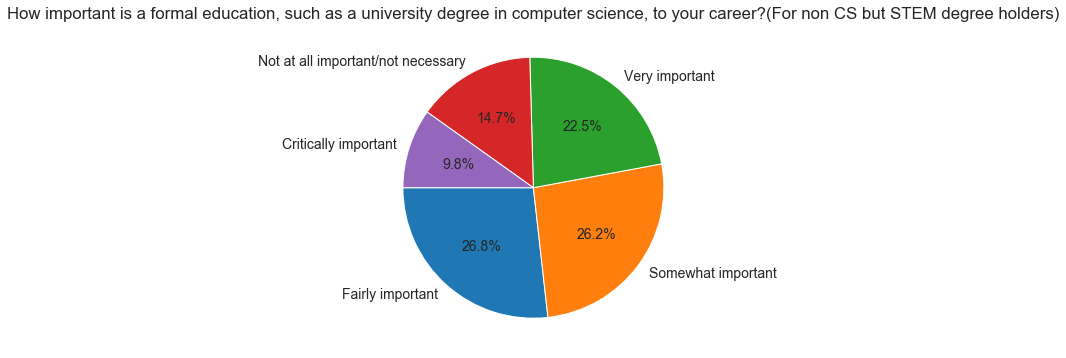

In [108]:
# Visualize how these people view their degrees
counts = stem_background['NEWEdImpt'].value_counts()

plt.figure(figsize=(12,6))
plt.title(schema.NEWEdImpt + '(For non CS but STEM degree holders)')
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=180);

In [109]:
# Extract out people with a non-STEM background
non_stem_background = survey_df.dropna(subset=['UndergradMajor', 'NEWEdImpt', 'EdLevel'])

# Filter out relevant majors
non_stem_terms = ['humanities ', 'arts', 'social', 'business']
non_stem_background = non_stem_background[non_stem_background['UndergradMajor'].str.contains('|'.join(non_stem_terms))]

# Filter out education level
degree_terms = ['Bachelor', 'Master']
non_stem_background = non_stem_background[non_stem_background['EdLevel'].str.contains('|'.join(degree_terms))]

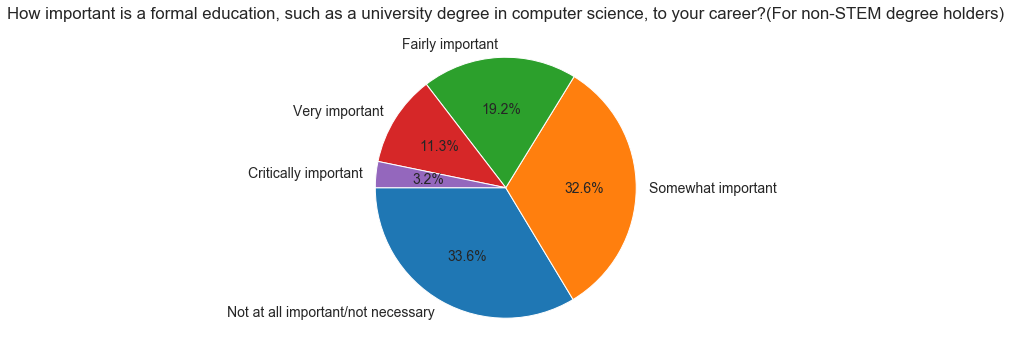

In [111]:
# Visualize how these people view their degrees
counts = non_stem_background['NEWEdImpt'].value_counts()

plt.figure(figsize=(12,6))
plt.title(schema.NEWEdImpt + '(For non-STEM degree holders)')
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=180);

### Employment

Freelancing or contract work is a common choice among programmer, so it would be interesting to compare the breakdown between full time, part time & freelance work. Let's visualize the data from `Employment` column.

In [115]:
schema.Employment

'Which of the following best describes your current employment status?'

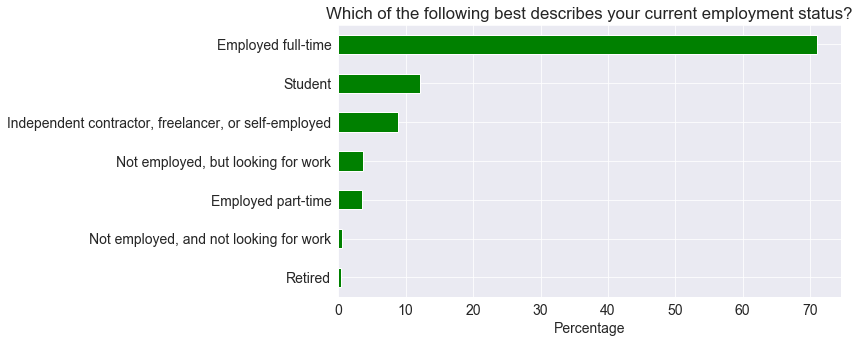

In [120]:
# We set normalize to True so that we can get percentages
(survey_df.Employment.value_counts(normalize=True, ascending=True)*100).plot(kind='barh', color='g')
plt.title(schema.Employment)
plt.xlabel('Percentage');

It appears that close to 10% of respondents are employed part time or as freelancers.

**Exercise**: Add a new column `EmploymentType` which contains values `Enthusiast` (student or not employed but looking for work), `Professional` (employed full-time, part-time or freelancing) and `Other` (not employed or retired). For each of the graphs that follow, show a comparison between `Enthusiast` and `Professional`.



The `DevType` field contains information about the roles held by respondents. Since the question allows multiple answers, the column contains lists of values separated by `;`, which makes it a bit harder to analyze directly.

In [121]:
schema.DevType

'Which of the following describe you? Please select all that apply.'

The above question allows the selection of multiple values.

';' indicates that multiple values are chosen

In [122]:
survey_df.DevType.value_counts()

Developer, full-stack                                                                                                                                                                     4375
Developer, back-end                                                                                                                                                                       3040
Developer, back-end;Developer, front-end;Developer, full-stack                                                                                                                            2201
Developer, back-end;Developer, full-stack                                                                                                                                                 1457
Developer, front-end                                                                                                                                                                      1385
                                             

Let's define a helper function which turns a column containing lists of values (like `survey_df.DevType`) into a data frame with one column for each possible option.

In [123]:
def split_multicolumn(col_series):
    result_df = col_series.to_frame()
    options = []
    
    # Iterate over the column
    for idx, value  in col_series[col_series.notnull()].iteritems():
        
        # Break each value into list of options
        for option in value.split(';'):
            
            # Add the option as a column to result
            if not option in result_df.columns:
                options.append(option)
                result_df[option] = False # Adds the column for the whole df, set all as False
                
            # Mark the value in the option column as True
            result_df.at[idx, option] = True
    return result_df[options]

In [124]:
dev_type_df = split_multicolumn(survey_df.DevType)

In [125]:
dev_type_df

,"Developer, desktop or enterprise applications","Developer, full-stack","Developer, mobile",Designer,"Developer, front-end","Developer, back-end","Developer, QA or test",DevOps specialist,"Developer, game or graphics",Database administrator,...,System administrator,Engineering manager,Product manager,Data or business analyst,Academic researcher,Data scientist or machine learning specialist,Scientist,Senior executive/VP,"Engineer, site reliability",Marketing or sales professional
0,True,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
64457,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Now, we can identify the most common roles

The `dev_type_df` has one column for each option that can be selected as a response. If a responded has selected the option, the value in the column is `True`, otherwise it is false.

We can now use the column-wise totals to identify the most common roles.

In [126]:
dev_type_totals = dev_type_df.sum().sort_values(ascending=False)
dev_type_totals

Developer, back-end                              26836
Developer, full-stack                            26753
Developer, front-end                             18020
Developer, desktop or enterprise applications    11625
Developer, mobile                                 9365
DevOps specialist                                 5870
Database administrator                            5621
Designer                                          5220
System administrator                              5137
Developer, embedded applications or devices       4674
Data or business analyst                          3944
Data scientist or machine learning specialist     3916
Developer, QA or test                             3865
Engineer, data                                    3681
Academic researcher                               3476
Educator                                          2873
Developer, game or graphics                       2718
Engineering manager                               2684
Product ma

As one might expect, the most common roles include "Developer" in the name. 

**Exercises**: 

* Can you figure out what percentage of respondents work in roles related to data science? 
* Which role has the highest percentage of women?
* You can merge this back with the original dataframe to do this.

We've only explore a handful of columns from the 20 columns that we selected. Explore and visualize the remaining columns using the empty cells below.

Let's save and upload our work before continuing.

In [59]:
import jovian

In [127]:
jovian.commit(project = project, filename = project)

<IPython.core.display.Javascript object>

[jovian] Attempting to save notebook..
[jovian] Updating notebook "hatziq/python-eda-stackoverflow-survey" on https://jovian.ml/
[jovian] Uploading notebook..
[jovian] Capturing environment..
[jovian] Committed successfully! https://jovian.ml/hatziq/python-eda-stackoverflow-survey


'https://jovian.ml/hatziq/python-eda-stackoverflow-survey'

## Asking and Answering Questions

We've already gained several insights about the respondents and the programming community in general, simply by exploring individual columns of the dataset. Let's ask some specific questions, and try to answer them using data frame operations and interesting visualizations.

#### Q: Which were the most popular programming languages in 2020? 

To answer, this we can use the `LanguageWorkedWith` column. Similar to `DevType` respondents were allowed to choose multiple options here.

In [129]:
schema.LanguageWorkedWith

'Which programming, scripting, and markup languages have you done extensive development work in over the past year, and which do you want to work in over the next year? (If you both worked with the language and want to continue to do so, please check both boxes in that row.)'

Above question has 2 parts, one for current year, the second for the next year.

In [128]:
survey_df.LanguageWorkedWith # First part of the question

0                                   C#;HTML/CSS;JavaScript
1                                         JavaScript;Swift
2                                 Objective-C;Python;Swift
3                                                      NaN
4                                        HTML/CSS;Ruby;SQL
                               ...                        
64456                                                  NaN
64457    Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...
64458                                                  NaN
64459                                             HTML/CSS
64460                      C#;HTML/CSS;Java;JavaScript;SQL
Name: LanguageWorkedWith, Length: 64306, dtype: object

In [130]:
survey_df.LanguageDesireNextYear # Second part of the question

0                                   C#;HTML/CSS;JavaScript
1                                             Python;Swift
2                                 Objective-C;Python;Swift
3                                                      NaN
4                                          Java;Ruby;Scala
                               ...                        
64456                                                  NaN
64457    Assembly;Bash/Shell/PowerShell;C;C#;C++;Dart;G...
64458                                                  NaN
64459                             HTML/CSS;Java;JavaScript
64460                      C#;HTML/CSS;Java;JavaScript;SQL
Name: LanguageDesireNextYear, Length: 64306, dtype: object

First, we'll split this column into a data frame containing a column of each languages listed in the options.

In [131]:
languages_worked_df = split_multicolumn(survey_df.LanguageWorkedWith)

In [63]:
languages_worked_df

,C#,HTML/CSS,JavaScript,Swift,Objective-C,Python,Ruby,SQL,Java,PHP,...,VBA,Perl,Scala,C++,Go,Haskell,Rust,Dart,Julia,Assembly
0,True,True,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,True,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64457,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


It appears that a total of 25 languages were included among the options. Let's aggregate these to identify the percentage of respondents who selected each language.

We can use .mean() as true = 1, false = 0. If we take a columnwise mean, we get the fraction of true values in the column. 

In [132]:
languages_worked_percentages = languages_worked_df.mean().sort_values(ascending=False) * 100
languages_worked_percentages

JavaScript               59.485896
HTML/CSS                 55.397630
SQL                      48.147918
Python                   38.669798
Java                     35.405716
Bash/Shell/PowerShell    28.972413
C#                       27.641278
PHP                      22.999409
TypeScript               22.322956
C++                      20.966939
C                        19.088421
Go                        7.674245
Kotlin                    6.837620
Ruby                      6.140951
Assembly                  5.382079
VBA                       5.355643
Swift                     5.198582
R                         5.008864
Rust                      4.411719
Objective-C               3.576649
Dart                      3.492676
Scala                     3.130346
Perl                      2.721363
Haskell                   1.816316
Julia                     0.774422
dtype: float64

We can plot this information using a horizontal bar chart.

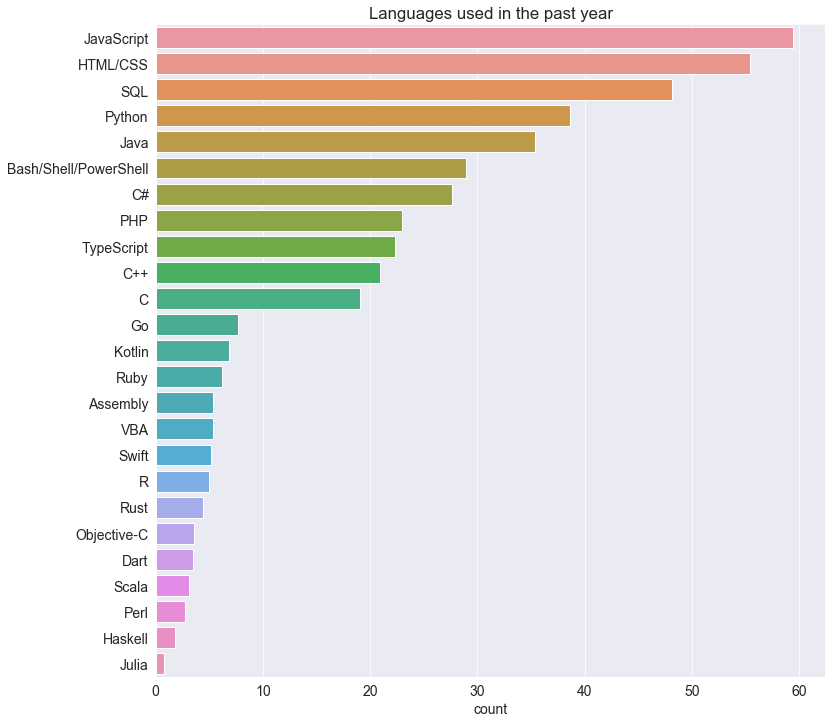

In [133]:
plt.figure(figsize=(12, 12))
sns.barplot(languages_worked_percentages, languages_worked_percentages.index)
plt.title("Languages used in the past year");
plt.xlabel('count');

Perhaps not surprisingly, Javascript & HTML/CSS comes out at the top as web development is one of the most sought skills today and it's also happens to be one of the easiest to get started with. SQL is necessary for working with relational databases, so it's no surprise that most programmers work with SQL on a regular basis. For other forms of development, Python seems be the popular choice, beating out Java, which was the industry standard for server & application development for over 2 decades.

**Exercises**:

* What are the most common languages used by students? How does the list compare with the most common languages used by professional developers? Is there a gap between education and the industry?
* What are the most common languages among respondents who do not describe themselves as "Developer, front-end"?
* What are the most common languages among respondents who work in fields related to data science?
* What are the most common languages used by developers older than 35 years of age? 
* What are the most common languages used by developers in your home country?

#### Q: Which languages are the most people interested to learn over the next year?

For this we can can use the `LanguageDesireNextYear` column, with similar processing as the previous one.

In [134]:
languages_interested_df = split_multicolumn(survey_df.LanguageDesireNextYear)
languages_interested_percentages = languages_interested_df.mean().sort_values(ascending=False) * 100
languages_interested_percentages

Python                   40.839113
JavaScript               40.175100
HTML/CSS                 31.793301
SQL                      30.586570
TypeScript               26.286816
C#                       20.923398
Java                     20.357354
Go                       19.298355
Bash/Shell/PowerShell    17.884801
Rust                     16.102696
C++                      14.891301
Kotlin                   14.676702
PHP                      10.871458
C                         9.277517
Swift                     8.649271
Dart                      7.279259
R                         6.511057
Ruby                      6.344665
Scala                     5.302771
Haskell                   4.525239
Assembly                  3.699499
Julia                     2.505209
Objective-C               2.323267
Perl                      1.743228
VBA                       1.600162
dtype: float64

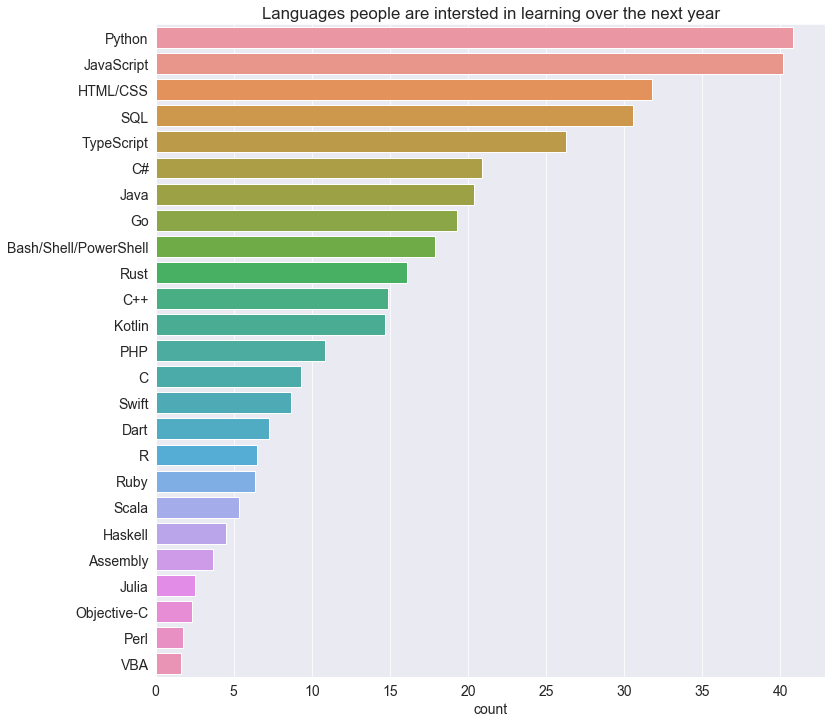

In [135]:
plt.figure(figsize=(12, 12))
sns.barplot(languages_interested_percentages, languages_interested_percentages.index)
plt.title("Languages people are intersted in learning over the next year");
plt.xlabel('count');

Once again, it's not surprising that Python is the language most people are interested in learning - since it is an easy-to-learn general purpose programming language well suited for a variety of domains: application development, numerical computing, data analysis, machine learning, big data, cloud automation, web scraping, scripting etc. etc. We're using Python for this very analysis, so we're in good company!

**Exercises**: Repeat all the exercises for the previous question, replacing "most common languages" with "languages people are interested in learning/using".

#### Q:  Which are the most loved languages i.e. a high percentage of people who have used the language want to continue learning & using it over the next year?

While this question may seem tricky at first, it's really easy to solve using Pandas array operations. Here's what we can do:

- Create a new data frame `languages_loved_df` which contains a `True` value for a language only if the corresponding values in `languages_worked_df` and `languages_interested_df` are both `True`
- Take the column wise sum of `languages_loved_df` and divide it by the column-wise sum of `languages_worked_df` to get the percentage of respondents who "love" the language
- Sort the results in decreasing order and plot a horizontal bar graph

In [136]:
True & False

False

In [137]:
# Does an element wise boolean operation
languages_loved_df = languages_worked_df & languages_interested_df

In [138]:
languages_loved_df

,Assembly,Bash/Shell/PowerShell,C,C#,C++,Dart,Go,HTML/CSS,Haskell,Java,...,Perl,Python,R,Ruby,Rust,SQL,Scala,Swift,TypeScript,VBA
0,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64456,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64457,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
64458,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
64459,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


True in one cell as both the cells must be True <br>
We define loved as if a person sets True to learning it this year and True to learning it next year

In [139]:
languages_loved_percentages = (languages_loved_df.sum() * 100/ languages_worked_df.sum()).sort_values(ascending=False)

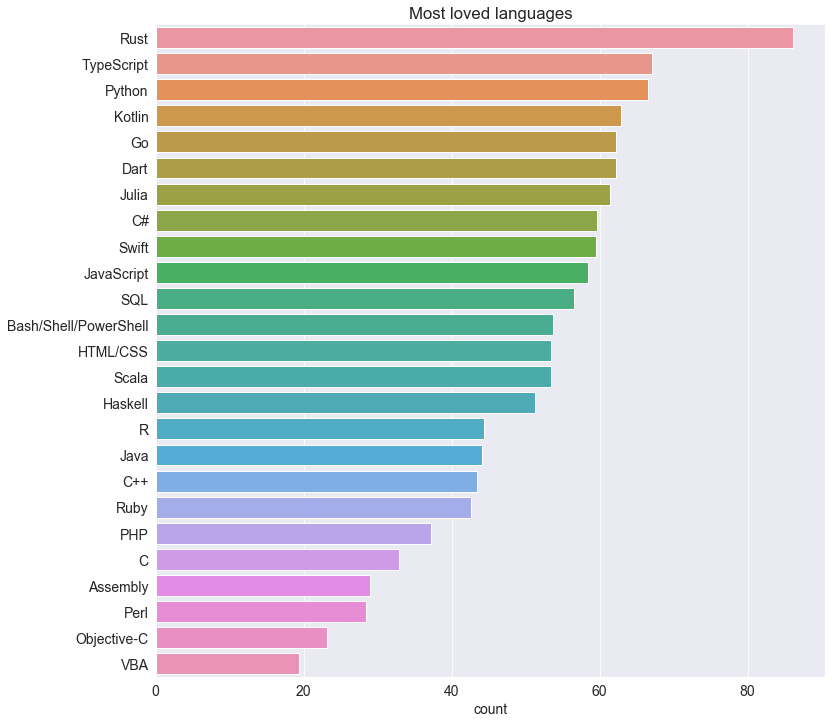

In [140]:
plt.figure(figsize=(12, 12))
sns.barplot(languages_loved_percentages, languages_loved_percentages.index)
plt.title("Most loved languages");
plt.xlabel('count');

[Rust](https://www.rust-lang.org) has been StackOverflow's most-loved language for [4 years in a row](https://stackoverflow.blog/2020/01/20/what-is-rust-and-why-is-it-so-popular/), followed by TypeScript which has gained a lot of popularity in the past few years as a good alternative to JavaScript for web development.

Python features at number 3, despite already being one of the most widely-used languages in world. This is testament to the fact the language has solid foundation, is really easy to learn & use, has a strong ecosystem of libraries for various and massive worldwide community of developers to enjoy using it.

**Exercises:** What are the _most dreaded languages_ i.e. languages which people have used in the past year, but do not want to learn/use over the next year. Hint: `~languages_interested_df`

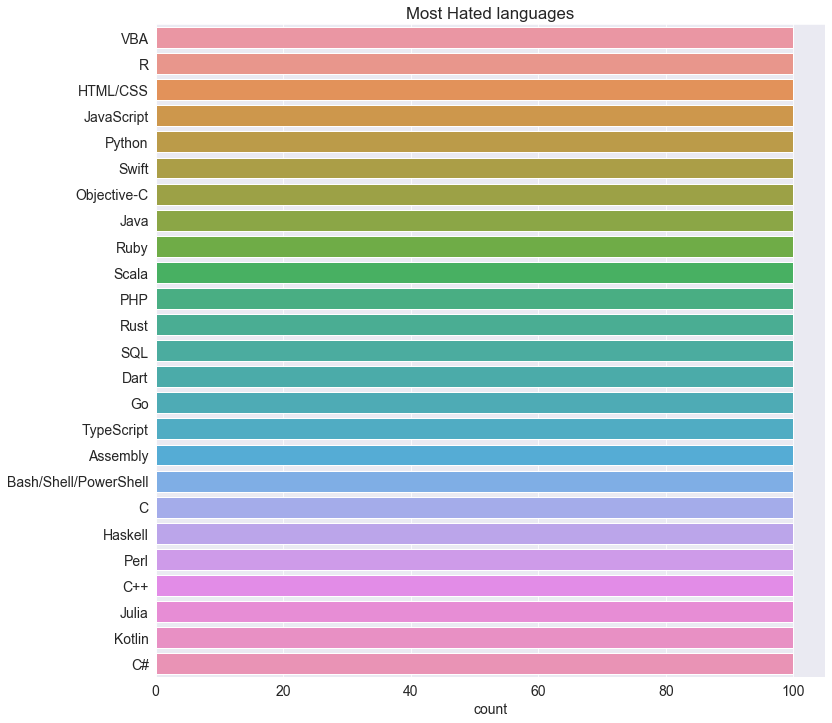

In [141]:
# The ~ sign is to invert the dataframe
languages_hated_df = ~languages_interested_df

languages_hated_percentages = (languages_hated_df.sum() * 100/ languages_hated_df.sum()).sort_values(ascending=False)

plt.figure(figsize=(12, 12))
sns.barplot(languages_hated_percentages, languages_hated_percentages.index)
plt.title("Most Hated languages");
plt.xlabel('count');

#### Q: In which countries do developers work the highest number of hours per week? Consider countries with more than 250 responses only.

To answer this question, we'll need to use the `groupby` data frame method to aggregate the rows for each country. We'll also need to filter the results to only include the countries which have more than 250 respondents.

In [144]:
countries_df = survey_df.groupby('Country')[['WorkWeekHrs', 'Age']].mean().sort_values('WorkWeekHrs', ascending=False)

In [145]:
high_response_countries_df = countries_df.loc[survey_df.Country.value_counts() > 250].head(15)

In [149]:
# View all countries
countries_df.loc[survey_df.Country.value_counts() > 200]

,WorkWeekHrs,Age
Country,,
Iran,44.580537,27.547826
Israel,43.912322,32.662105
China,42.150000,27.028736
United States,41.816542,33.778208
Viet Nam,41.391667,25.785276
Greece,41.170588,31.776316
South Africa,41.017699,32.165761
Turkey,40.982143,29.533730
Nepal,40.798319,24.416667


In [150]:
high_response_countries_df

,WorkWeekHrs,Age
Country,,
Iran,44.580537,27.547826
Israel,43.912322,32.662105
China,42.150000,27.028736
United States,41.816542,33.778208
Viet Nam,41.391667,25.785276
Greece,41.170588,31.776316
South Africa,41.017699,32.165761
Turkey,40.982143,29.533730
Sri Lanka,40.496552,26.982759


The Asian countries like Iran, China & Israel have the highest working hours, followed by the United States. However, there isn't too much variation overall and the average working hours seem to be around 40 hours per week.

**Exercises:**

* How to the average work hours compare across continents? You may find this list of [countries in each continent](https://hub.jovian.ml/wp-content/uploads/2020/09/countries.csv) useful.
* Which role has the highest average number of hours worked per week? Which role has the lowest?
* How do the hours worked compare between freelancers and developers working full-time? Do freelancers work less?

#### Q: How important is it to start young to build a career in programming?

Let's create a scatter plot of `Age` vs. `YearsCodePro` (i.e. years of coding experience) to answer this question.

In [151]:
schema.YearsCodePro

'NOT including education, how many years have you coded professionally (as a part of your work)?'

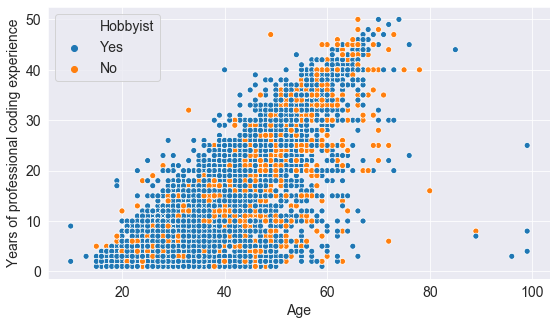

In [152]:
sns.scatterplot('Age', 'YearsCodePro', hue='Hobbyist', data=survey_df)
plt.xlabel("Age")
plt.ylabel("Years of professional coding experience");

You can see points all over the graph, which seems to indicate that you can **start programming professionally at any age**. Also, many people who have been coding for several decades professionally also seem to enjoy it has a hobby.

We can also view the distribution of `Age1stCode` column to see when the respondents tried programming for the first time.

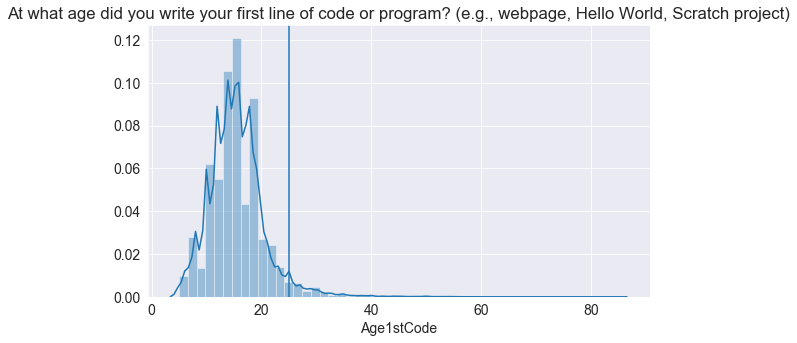

In [155]:
plt.title(schema.Age1stCode)
plt.axvline(25, 0, 1, label='pyplot vertical line')
sns.distplot(survey_df.Age1stCode);

As you might expect, most people seem to have had some exposure to programming before the age of 40, but there are people of all ages and walks of life who are learning to code.

**Exercises**:
* How does experience change opinions & preferences? Repeat the entire analysis while comparing the responses of people who have more than 10 years of professional programming experience v.s. those who don't. Do you see any interesting trends?
* Compare the years of professional coding experience across different genders. 


We've barely scratched the surface here, and hopefully you are already thinking of many more questions that you'd like to answer using this data. Use the empty cells to below to ask and answer more questions.

Let's save and commit our work before continuing

In [80]:
import jovian

In [ ]:
jovian.commit(project = project, filename = project)

<IPython.core.display.Javascript object>

[jovian] Attempting to save notebook..


## Inferences and Conclusions

We've drawn many interesting inferences from the survey, here's a summary of the few of them:

- Based on the demographics of the survey respondents, we can infer that the survey is somewhat representative of the overall programming community, although it definitely has fewer responses from programmers in non-English-speaking countries and from women & non-binary genders.

- The programming community is not as diverse as it can be, and although things are improving, we should take more efforts to support & encourage members of underrepresented communities - whether it is in terms of age, country, race, gender or otherwise.

- Most programmers hold a college degree, although a fairly large percentage did not have computer science as their major in college, so a computer science degree isn't compulsory for learning to code or building a career in programming.

- A significant percentage of programmers either work part time or as freelancers, and this can be a great way to break into the field, especially when you're just getting started.

- Javascript & HTML/CSS are the most used programming languages in 2020, closely followed by SQL & Python

- Python is the language most people are interested in learning - since it is an easy-to-learn general purpose programming language well suited for a variety of domains.

- Rust and TypeScript are the most "loved" languages in 2020, both of which have small but fast-growing communities. Python is a close third, despite already being a widely used language.

- Programmers around the world seems be working for around 40 hours a week on average, with slight variations by country.

- You can learn and start programming professionally at any age, and you're likely to have a long and fulfilling career if you also enjoy programming as a hobby.


## References and Future Work

There's a wealth of information to be discovered using the survey, and we've barely scratched the surface. Here are some ideas for further exploration:

- Repeat the analysis for different age groups & genders, and compare the results
- Choose a different set of columns (we chose on 20 out of 65) to analyze other facets of the data
- Prepare an analysis focusing on diversity - and identify areas where underrepresented communities are at par with the majority (e.g. education) and where they aren't (e.g. salaries)
- Compare the results of this year's survey with the previous years and identify interesting trends

References:

- Stack Overflow Developer Survey: https://insights.stackoverflow.com/survey
- Pandas user guide: https://pandas.pydata.org/docs/user_guide/index.html
- Matplotlib user guide: https://matplotlib.org/3.3.1/users/index.html
- Seaborn user guide & tutorial: https://seaborn.pydata.org/tutorial.html
- `opendatasets` Python library: https://github.com/JovianML/opendatasets

As a next step, you can try out a project on another dataset of your choice: https://jovian.ml/aakashns/zerotopandas-course-project-starter

In [82]:
import jovian

In [ ]:
jovian.commit()

<IPython.core.display.Javascript object>

[jovian] Attempting to save notebook..
